# Customer Purchase Behavior Analysis

## Goal
### Analyze 3,900 customer shopping records to answer:
### - Which product categories and seasons drive the most revenue?
### - Does subscription status or discount usage affect spending?
### - How does customer age relate to purchase frequency and amount?

## How to use this Jupyter Notebook

### Requirements:
### - Libraries: "pandas", "matplotlib", "seaborn", "requests", "python-dotenv"
### - [Ollama](https://ollama.com) installed and running locally with "gemma3:4b" pulled

### Setup steps:
### 1. Clone the repository and navigate to the project folder
### 2. Install dependencies: "pip install pandas matplotlib seaborn requests python-dotenv"
### 3. Pull the local LLM: "ollama pull gemma3:4b", then start it: "ollama serve"
### 4. Place "shopping_trends.csv" in the same folder as this notebook
### 5. Run all cells top to bottom: Kernel → Restart & Run All

### Output files generated:
### - "shopping_trends_raw.csv" — original data backup
### - "shopping_trends_cleaned.csv" — cleaned data with AI insights
### - "results_by_category.csv" — category revenue summary
### - "results_by_season.csv" — seasonal spending summary
### - "results_discount_impact.csv" — discount impact analysis

## Data Source
### Kaggle: Customer Purchase Behavior Analysis (3,900 rows, 19 columns)

# Part 1: Load data

In [6]:
import pandas as pd

# Load and save the raw CSV
df_raw = pd.read_csv("shopping_trends.csv")
df_raw.to_csv("shopping_trends_raw.csv", index=False)

# Preview
print(f"Shape: {df_raw.shape}")
display(df_raw.head())

Shape: (3900, 19)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


# Part 2: Clean and transform

In [8]:
df = df_raw.copy()

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Convert Yes/No columns to boolean
for col in ["Subscription Status", "Discount Applied", "Promo Code Used"]:
    df[col] = df[col].map({"Yes": True, "No": False})

# Define age groups for easier analysis
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 100],
    labels=["18–25", "26–35", "36–50", "51+"]
)

print("\nData types after cleaning:")
print(df.dtypes)
print("\nSample after cleaning:")
display(df.head())

Missing values per column:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Data types after cleaning:
Customer ID                    int64
Age                            int64
Gender                        object
Item Purchased                object
Category                      object
Purchase Amount (USD)          int64
Location                      object
Size                          object
Color                         object
Season                       

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,True,Credit Card,Express,True,True,14,Venmo,Fortnightly,51+
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,True,Bank Transfer,Express,True,True,2,Cash,Fortnightly,18–25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,True,Cash,Free Shipping,True,True,23,Credit Card,Weekly,36–50
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,True,PayPal,Next Day Air,True,True,49,PayPal,Weekly,18–25
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,True,Cash,Free Shipping,True,True,31,PayPal,Annually,36–50


# Part 3: Analysis and visualizations

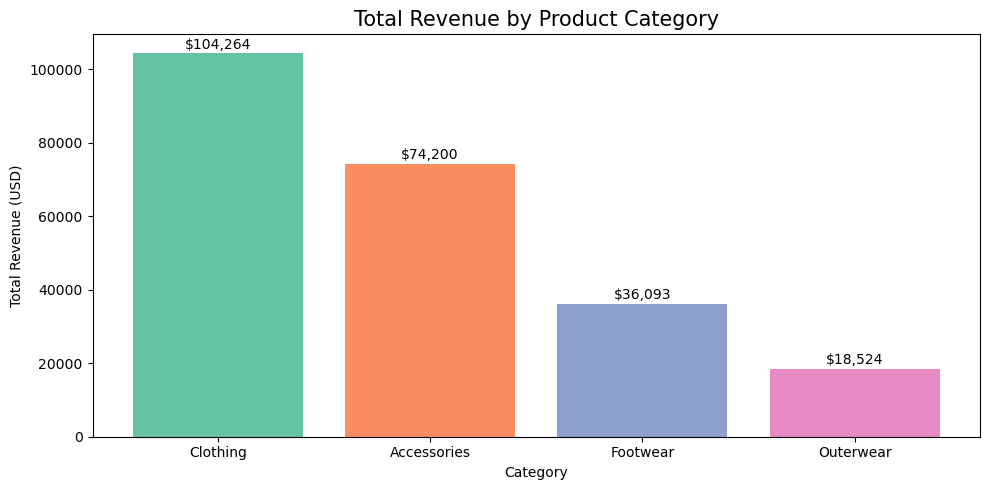

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

category_revenue = df.groupby("Category")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

bars = ax.bar(category_revenue.index, category_revenue.values, color=sns.color_palette("Set2"))
ax.set_title("Total Revenue by Product Category", fontsize=15)
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue (USD)")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

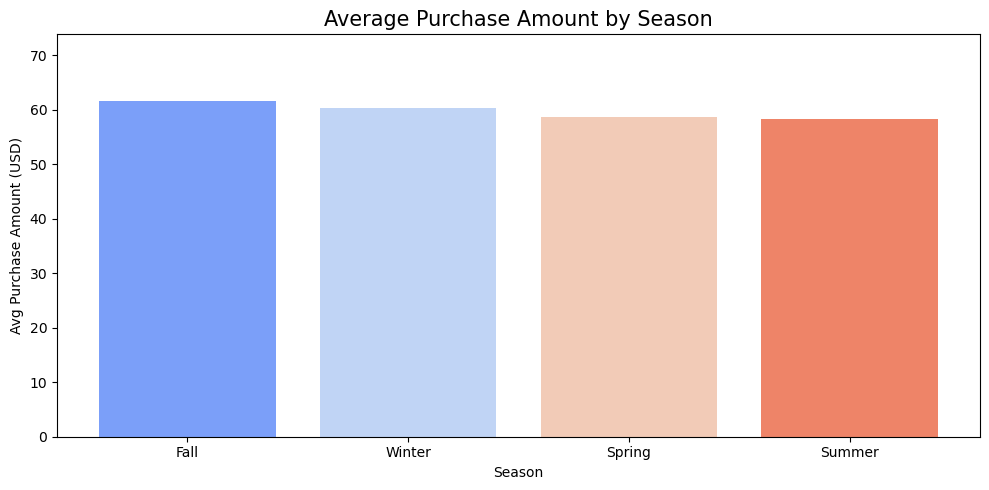

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))

season_avg = df.groupby("Season")["Purchase Amount (USD)"].mean().sort_values(ascending=False)

ax.bar(season_avg.index, season_avg.values, color=sns.color_palette("coolwarm", 4))
ax.set_title("Average Purchase Amount by Season", fontsize=15)
ax.set_xlabel("Season")
ax.set_ylabel("Avg Purchase Amount (USD)")
ax.set_ylim(0, season_avg.max() * 1.2)

plt.tight_layout()
plt.show()

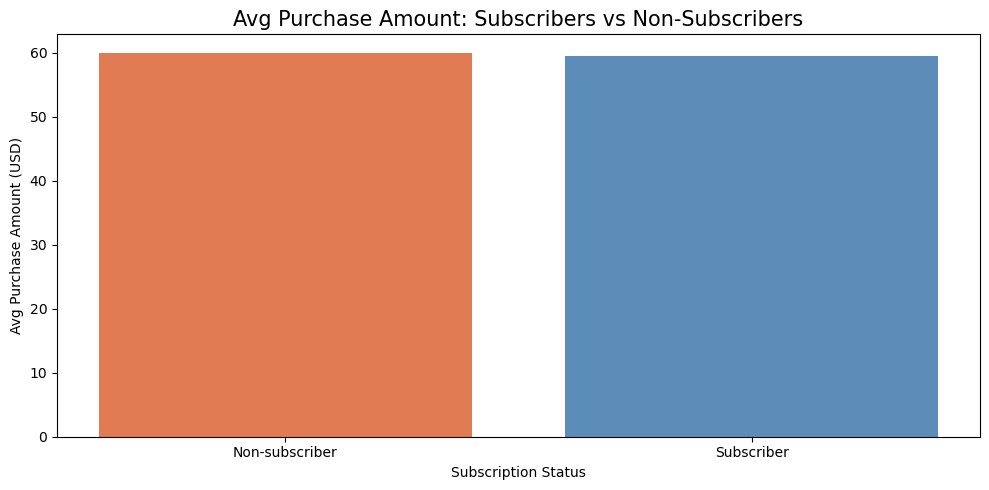

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))

sub_avg = df.groupby("Subscription Status")["Purchase Amount (USD)"].mean()
labels = ["Non-subscriber", "Subscriber"]

ax.bar(labels, sub_avg.values, color=["#E07B54", "#5B8DB8"])
ax.set_title("Avg Purchase Amount: Subscribers vs Non-Subscribers", fontsize=15)
ax.set_xlabel("Subscription Status")
ax.set_ylabel("Avg Purchase Amount (USD)")

plt.tight_layout()
plt.show()

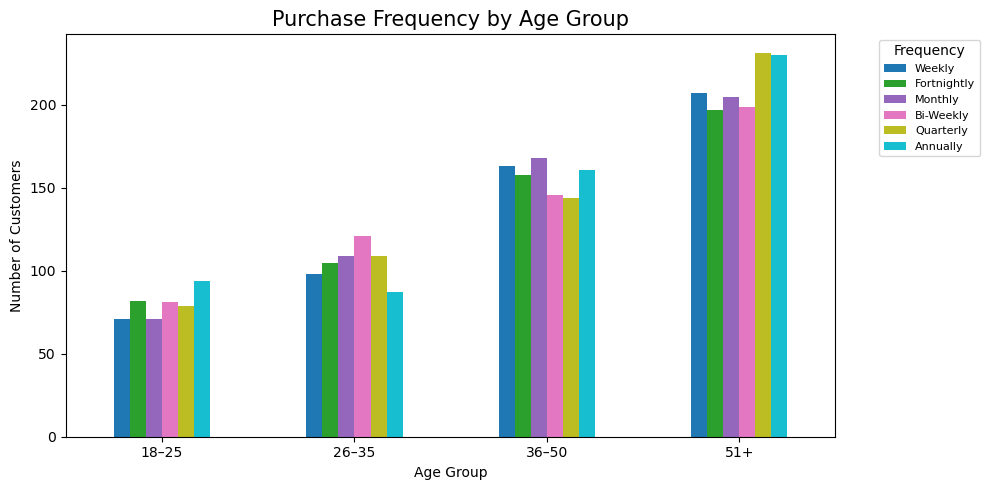

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

freq_order = ["Weekly", "Fortnightly", "Monthly", "Bi-Weekly", "Quarterly", "Annually"]
age_freq = df.groupby(["Age Group", "Frequency of Purchases"], observed=True).size().reset_index(name="Count")

pivot = age_freq.pivot(index="Age Group", columns="Frequency of Purchases", values="Count").fillna(0)
pivot[freq_order] = pivot.reindex(columns=freq_order, fill_value=0)

pivot[freq_order].plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Purchase Frequency by Age Group", fontsize=15)
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Customers")
ax.legend(title="Frequency", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
print("Key Statistics")
print(f"Average purchase amount: ${df['Purchase Amount (USD)'].mean():.2f}")
print(f"Top category by revenue: {category_revenue.idxmax()}")
print(f"Top season by avg spend: {season_avg.idxmax()}")
print(f"Correlation — age vs purchase amount:")
print(f"  r = {df['Age'].corr(df['Purchase Amount (USD)']):.3f}")
print(f"Discount impact on avg spend:")
display(df.groupby("Discount Applied")["Purchase Amount (USD)"].mean().rename({True: "With discount", False: "No discount"}))

Key Statistics
Average purchase amount: $59.76
Top category by revenue: Clothing
Top season by avg spend: Fall
Correlation — age vs purchase amount:
  r = -0.010
Discount impact on avg spend:


Discount Applied
No discount      60.130454
With discount    59.279070
Name: Purchase Amount (USD), dtype: float64

# Part 4: API Enrichment (Local LLM via Ollama)

In [44]:
import requests

def get_category_insight(category, avg_spend, top_season):
    """Use local Gemma3 via Ollama to generate a retail insight."""
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": "gemma3:4b",
            "prompt": (
                f"In one sentence, give a retail business insight for the '{category}' "
                f"category, where average spend is ${avg_spend:.2f} and peak season is {top_season}."
            ),
            "stream": False
        }
    )

    if response.status_code != 200:
        print(f"Error {response.status_code}: {response.text}")
        return "No insight available"

    return response.json()["response"].strip()

In [60]:
# Compute stats per category
category_stats = df.groupby("Category").agg(
    avg_spend=("Purchase Amount (USD)", "mean"),
    top_season=("Season", lambda x: x.value_counts().idxmax())
).reset_index()

print("AI insights per category\n")
insights = []
for _, row in category_stats.iterrows():
    insight = get_category_insight(row["Category"], row["avg_spend"], row["top_season"])
    insights.append(insight)
    print(f"[{row['Category']}] {insight}\n")

category_stats["AI Insight"] = insights
display(category_stats)

AI insights per category

[Accessories] Retailers in the accessories category should focus on driving higher-value purchases, particularly during the Fall season when average spend is highest, by offering curated bundles and capitalizing on seasonal trends and promotions.

[Clothing] To maximize sales in the clothing category with an average spend of $60.03 and a strong Spring peak, retailers should focus on targeted promotions and new arrivals around the Spring season while offering value-driven items to encourage purchases.

[Footwear] With an average spend of $60.26 and a strong peak during Spring, footwear retailers should focus on offering seasonally relevant styles and promotions to capitalize on increased demand and drive higher transaction values.

[Outerwear] Retailers in the outerwear category should focus on offering high-quality, stylish options priced around $57.17, capitalizing on the peak Fall season with targeted marketing and promotions to drive sales during this cruci

,Category,avg_spend,top_season,AI Insight
0,Accessories,59.838710,Fall,Retailers in the accessories category should f...
1,Clothing,60.025331,Spring,To maximize sales in the clothing category wit...
2,Footwear,60.255426,Spring,With an average spend of $60.26 and a strong p...
3,Outerwear,57.172840,Fall,Retailers in the outerwear category should foc...


# Part 5: Export Results

In [61]:
# Export cleaned dataframe with AI insights merged in
df_export = df.merge(
    category_stats[["Category", "AI Insight"]],
    on="Category",
    how="left"
)
df_export.to_csv("shopping_trends_cleaned.csv", index=False)
print(df_export.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  ...  Subscription Status  \
0       Kentucky    L       Gray  Winter  ...                 True   
1          Maine    L     Maroon  Winter  ...                 True   
2  Massachusetts    S     Maroon  Spring  ...                 True   
3   Rhode Island    M     Maroon  Spring  ...                 True   
4         Oregon    M  Turquoise  Spring  ...                 True   

   Payment Method  Shipping Type Discount Applied  Promo Code Used  \
0     Credit Card        Express        

In [62]:
# Export category summary with AI insights
category_stats.rename(columns={
    "avg_spend": "Avg Spend (USD)",
    "top_season": "Peak Season"
}, inplace=True)

category_stats.to_csv("results_by_category.csv", index=False)
print("Category summary exported: results_by_category.csv")
display(category_stats)

Category summary exported: results_by_category.csv


,Category,Avg Spend (USD),Peak Season,AI Insight
0,Accessories,59.838710,Fall,Retailers in the accessories category should f...
1,Clothing,60.025331,Spring,To maximize sales in the clothing category wit...
2,Footwear,60.255426,Spring,With an average spend of $60.26 and a strong p...
3,Outerwear,57.172840,Fall,Retailers in the outerwear category should foc...


In [63]:
# Export season summary
season_summary = (
    df.groupby("Season")["Purchase Amount (USD)"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "Avg Spend (USD)", "sum": "Total Revenue (USD)", "count": "Num Customers"})
    .sort_values("Total Revenue (USD)", ascending=False)
    .reset_index()
)
season_summary.to_csv("results_by_season.csv", index=False)
print("Season summary exported: results_by_season.csv")
display(season_summary)

Season summary exported: results_by_season.csv


,Season,Avg Spend (USD),Total Revenue (USD),Num Customers
0,Fall,61.556923,60018,975
1,Spring,58.737738,58679,999
2,Winter,60.357364,58607,971
3,Summer,58.405236,55777,955


In [64]:
# Export discount impact summary
discount_summary = (
    df.groupby("Discount Applied")["Purchase Amount (USD)"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "Avg Spend (USD)", "count": "Num Customers"})
    .rename(index={True: "With Discount", False: "No Discount"})
    .reset_index()
)
discount_summary.to_csv("results_discount_impact.csv", index=False)
print("Discount impact exported: results_discount_impact.csv")
display(discount_summary)

Discount impact exported: results_discount_impact.csv


,Discount Applied,Avg Spend (USD),Num Customers
0,No Discount,60.130454,2223
1,With Discount,59.279070,1677


# Conclusion

### This analysis explored 3,900 customer purchase records across 4 product categories to understand what drives shopping behavior.
### Key findings:

### 1. Clothing dominates revenue: Clothing is the top category by total revenue, followed closely by Accessories, Footwear, and Outerwear.

### 2. Fall is the peak spending season: Both Accessories and Outerwear peak in Fall, while Clothing and Footwear peak in Spring, suggesting seasonal inventory planning should differ by category.

### 3. Discounts don't increase spending: Customers without discounts spent slightly more on average. This suggests discounts may attract more price-sensitive buyers rather than driving higher-value purchases.

### 4. Age has almost no effect on purchase amount: The correlation between age and purchase amount is r = -0.010, essentially zero. Age group does not predict how much a customer spends.

### 5. Older customers (51+) purchase most frequently: The 51+ age group has the highest counts across Weekly and Quarterly purchase frequencies, making them the most engaged segment.

### 6. AI-generated insights (via Gemma3:4b) confirmed that each category benefits from season-specific targeted promotions, and that retailers should focus marketing efforts around their respective peak seasons.

### Business recommendation:  Focus seasonal promotions by category rather than store-wide, and reconsider blanket discount strategies as they do not appear to drive higher spending.

# Pipeline overview:

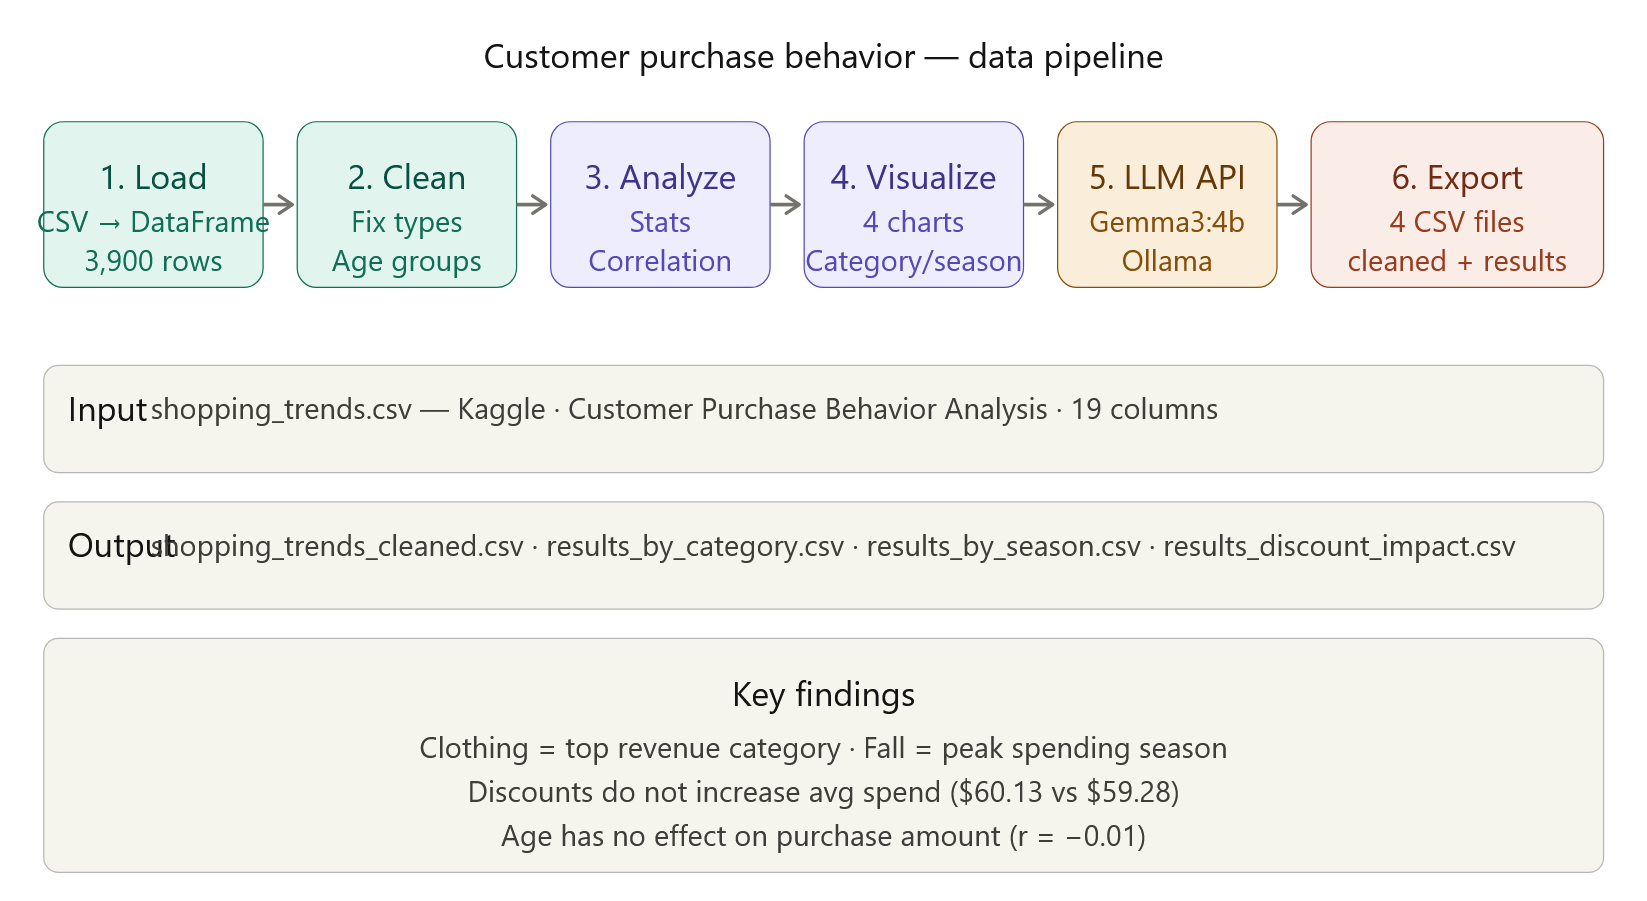

In [75]:
from IPython.display import Image, display
display(Image("data pipeline.png"))

# Statement of AI Use

## Claude was used to help structure the project outline, suggest relevant visualizations for this dataset, create data pipeline image, and debug code errors. 
## Gemma3:4b (via Ollama) was used inside the notebook itself to generate category insights from the analyzed data. 
## All chart interpretations, conclusions, and analytical decisions were made independently.